In [1]:
print("hello")

hello


Project #1 - environment configuration

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import dcc
from dash import html
from dash.dependencies import Input, Output

Project #1 - importing data

In [3]:
df = pd.read_csv("project_1_python.csv")

# null values are messing up map creating exercise below,
# so I just get rid of them:
df = df.dropna(subset=["total_cases"])
# renaming otherwise confusing column which I use many times below:
df = df.rename(columns={"location":"country"})


df

,index,iso_code,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,hosp_patients,...,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,population,median_age,gdp_per_capita,life_expectancy,latitude,longitude
0,0,AFG,Asia,Afghanistan,2020-02-24,5.0,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
1,1,AFG,Asia,Afghanistan,2020-02-25,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
2,2,AFG,Asia,Afghanistan,2020-02-26,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
3,3,AFG,Asia,Afghanistan,2020-02-27,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
4,4,AFG,Asia,Afghanistan,2020-02-28,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180472,190608,ZWE,Africa,Zimbabwe,2022-06-14,254155.0,0.0,5521.0,0.0,NaN,...,6270096.0,4563366.0,1026048.0,NaN,15092171.0,19.6,1899.775,61.49,-20.0,30.0
180473,190609,ZWE,Africa,Zimbabwe,2022-06-15,254387.0,232.0,5525.0,4.0,NaN,...,6271703.0,4567466.0,1027822.0,7481.0,15092171.0,19.6,1899.775,61.49,-20.0,30.0
180474,190610,ZWE,Africa,Zimbabwe,2022-06-16,254502.0,115.0,5526.0,1.0,NaN,...,6274305.0,4570349.0,1029463.0,7126.0,15092171.0,19.6,1899.775,61.49,-20.0,30.0
180475,190611,ZWE,Africa,Zimbabwe,2022-06-17,254753.0,251.0,5533.0,7.0,NaN,...,6276402.0,4574222.0,1031790.0,8297.0,15092171.0,19.6,1899.775,61.49,-20.0,30.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 173493 entries, 0 to 180476
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   index                    173493 non-null  int64  
 1   iso_code                 173493 non-null  str    
 2   continent                173493 non-null  str    
 3   country                  173493 non-null  str    
 4   date                     173493 non-null  str    
 5   total_cases              173493 non-null  float64
 6   new_cases                173212 non-null  float64
 7   total_deaths             155322 non-null  float64
 8   new_deaths               155094 non-null  float64
 9   hosp_patients            27143 non-null   float64
 10  total_tests              74947 non-null   float64
 11  new_tests                71213 non-null   float64
 12  tests_per_case           89671 non-null   float64
 13  total_vaccinations       46109 non-null   float64
 14  people_vaccinated   

Project #1 - first visualization

In [5]:
df_countries = df[["iso_code","continent","country","population","life_expectancy"]].drop_duplicates()
df_countries = df_countries.sort_values(by="population",ascending=False)

ten_top_pop_countries = df_countries.head(10)

ten_top_pop_countries


,iso_code,continent,country,population,life_expectancy
33499,CHN,Asia,China,1.444216e+09,76.91
74570,IND,Asia,India,1.393409e+09,69.66
170959,USA,North America,United States,3.329151e+08,78.86
75441,IDN,Asia,Indonesia,2.763618e+08,71.72
122998,PAK,Asia,Pakistan,2.251999e+08,67.27
21805,BRA,South America,Brazil,2.139934e+08,75.88
118134,NGA,Africa,Nigeria,2.114007e+08,54.69
12663,BGD,Asia,Bangladesh,1.663035e+08,72.59
133450,RUS,Europe,Russia,1.459120e+08,72.58
103908,MEX,North America,Mexico,1.302622e+08,75.05


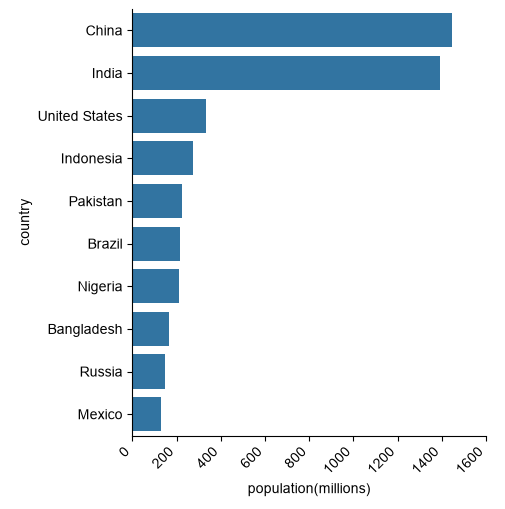

In [6]:
graph = sns.catplot(
    data=ten_top_pop_countries,
    x=ten_top_pop_countries["population"]/1e6,
    y=ten_top_pop_countries["country"],
    kind="bar")

sns.set_style("whitegrid")
plt.xlabel("population(millions)")
graph.set_xticklabels(rotation=45, ha="right")

Project #1 - population vs. life expectancy

In [7]:
fig = px.scatter(
    data_frame=df_countries,
    x="population",
    y="life_expectancy",
    title="Population vs life expectancy",
    log_x=True,
    color="continent",
    hover_name="country",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.show()

Project #1 - number of diagnosed cases

In [8]:
df_cz_de = df[df["country"].isin(["Czechia","Germany"])]

df_cz_de

,index,iso_code,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,hosp_patients,...,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,population,median_age,gdp_per_capita,life_expectancy,latitude,longitude
41385,43877,CZE,Europe,Czechia,2020-03-01,3.0,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10724553.0,43.3,32605.906,79.38,49.75,15.5
41386,43878,CZE,Europe,Czechia,2020-03-02,3.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10724553.0,43.3,32605.906,79.38,49.75,15.5
41387,43879,CZE,Europe,Czechia,2020-03-03,5.0,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10724553.0,43.3,32605.906,79.38,49.75,15.5
41388,43880,CZE,Europe,Czechia,2020-03-04,8.0,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10724553.0,43.3,32605.906,79.38,49.75,15.5
41389,43881,CZE,Europe,Czechia,2020-03-05,12.0,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10724553.0,43.3,32605.906,79.38,49.75,15.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61546,64038,DEU,Europe,Germany,2022-06-14,27007429.0,92344.0,140026.0,112.0,NaN,...,64560449.0,64532312.0,55029890.0,44205.0,83900471.0,46.6,45229.245,81.33,51.00,9.0
61547,64039,DEU,Europe,Germany,2022-06-15,27096571.0,89142.0,140099.0,73.0,NaN,...,64562027.0,64534521.0,55070933.0,44832.0,83900471.0,46.6,45229.245,81.33,51.00,9.0
61548,64040,DEU,Europe,Germany,2022-06-16,27124689.0,28118.0,140118.0,19.0,NaN,...,64562858.0,64536156.0,55093502.0,25031.0,83900471.0,46.6,45229.245,81.33,51.00,9.0
61549,64041,DEU,Europe,Germany,2022-06-17,27204953.0,80264.0,140176.0,58.0,NaN,...,64563521.0,64537461.0,55117405.0,25869.0,83900471.0,46.6,45229.245,81.33,51.00,9.0


In [9]:
fig = px.line(
    data_frame=df_cz_de,
    x="date",
    y="new_cases",
    color="country",
    color_discrete_sequence=px.colors.qualitative.Antique,
    title="Covid cases in Czechia vs Germany over time"
)

fig.show()

In [10]:
# now I am going to rescale it to population of both countries:

df_cz_de["new_cases_per_1000_people"] = df_cz_de["new_cases"]/df_cz_de["population"]/1000

fig = px.line(
    data_frame=df_cz_de,
    x="date",
    y="new_cases_per_1000_people",
    color="country",
    color_discrete_sequence=px.colors.qualitative.Antique,
    title="Covid cases in Czechia vs Germany per thousand people over time"
)

# this line is from Claude, it fixes y axis values to something not containing Greek letters:
fig.update_yaxes(exponentformat="none") 

fig.show()

Project #1 - COVID-19 map

In [11]:

"""
I am not sure how to understand
the task "2. Make the size of the marker dependent on the ratio of cases to population in the country."
There are multiple values of total cases for each country.
Anyway, I've decided to pick the highest value, presumably this is total cases for all time 
(to publication of dataset, anyway).
"""
df_countries2 = df.sort_values("total_cases", ascending=False).drop_duplicates(subset="country", keep="first")

df_countries2["cases_to_population"] = df_countries2["total_cases"]/df_countries2["population"]

fig = px.scatter_geo(
    data_frame=df_countries2,
    locations="iso_code",
    locationmode="ISO-3",      
    color="continent",
    size="cases_to_population",             
    hover_name="country",       
    hover_data="total_cases",
    title="Cases to population"
)

fig.update_layout(template="plotly_dark",height=800)

fig.show()


Project #1 - dashboard #1

In [12]:
app = dash.Dash()

font_styles={"fontFamily": "verdana", "color": "#444"}

app.layout = html.Div(
    [html.H3(id="title", style=font_styles),
     
dcc.Dropdown(
        id="country-picker",
        clearable=False,
        options=[{"label": country, "value": country} 
                 for country in df["country"].unique()],
        value = "Czechia",
        style=font_styles
        ),
html.Div([
dcc.Graph(id="graph_cases", style={'width': '50%'}),
dcc.Graph(id="graph_deaths", style={'width': '50%'})
], style = {"display":"flex"})

])

@app.callback(
    Output("title", "children"),
    Output("graph_cases", "figure"),
    Output("graph_deaths", "figure"),
    Input("country-picker","value")
)
def update_dashboard(country):
    title = f"Cumulative number of positive cases and deaths in {country}"
    selected_country = df[df["country"] == country]
    cases = px.line(selected_country, x="date", y="total_cases")
    deaths = px.line(selected_country, x="date", y="total_deaths")
    return title, cases, deaths

if __name__ == "__main__":
    app.run(debug=True, host="127.0.0.1", port=8050)

Project #1 - dashboard #2

In [26]:
df_sorted_by_date = df.sort_values(
    by="date",
    ascending=False,
    na_position="last"
)

last_day = df_sorted_by_date.head(1)["date"]

print(last_day)

df_sorted_by_date

180476    2022-06-18
Name: date, dtype: str


,index,iso_code,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,hosp_patients,...,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,population,median_age,gdp_per_capita,life_expectancy,latitude,longitude
180476,190612,ZWE,Africa,Zimbabwe,2022-06-18,254753.0,NaN,5533.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.509217e+07,19.6,1899.775,61.49,-20.0000,30.0000
178031,188167,WLF,Oceania,Wallis and Futuna,2022-06-18,454.0,0.0,7.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.109400e+04,NaN,NaN,79.94,-13.3000,-176.2000
84361,86853,JOR,Asia,Jordan,2022-06-18,1697673.0,NaN,14068.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.026902e+07,23.2,8337.490,74.53,31.0000,36.0000
137439,142452,LCA,North America,Saint Lucia,2022-06-18,26722.0,18.0,376.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.844010e+05,34.9,12951.839,76.20,13.8833,-61.1333
38877,41368,CIV,Africa,Cote d'Ivoire,2022-06-18,82659.0,0.0,801.0,0.0,NaN,...,NaN,NaN,NaN,NaN,2.705363e+07,18.7,3601.006,57.78,8.0000,-5.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170959,179390,USA,North America,United States,2020-01-22,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.329151e+08,38.3,54225.446,78.86,38.0000,-97.0000
160462,168893,THA,Asia,Thailand,2020-01-22,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.995084e+07,40.1,16277.671,77.15,15.0000,100.0000
157961,165513,TWN,Asia,Taiwan,2020-01-22,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.385501e+07,42.2,NaN,80.46,23.5000,121.0000
95553,98882,MAC,Asia,Macao,2020-01-22,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.583910e+05,39.2,104861.851,84.24,22.1667,113.5500


In [ ]:
df_last_day = df_sorted_by_date[df_sorted_by_date["date"] == last_day]

df_last_day

ValueError: Can only compare identically-labeled Series objects

In [ ]:
app = dash.Dash()

font_styles={"fontFamily": "verdana", "color": "#444"}

app.layout = html.Div([
    
    html.H2(id="title"),

    html.Div([

    html.Div([
    html.H3("Continent:"),
    dcc.Dropdown(
        id="continent-picker",
        options=[{"label": continent, "value": continent} 
                 for continent in df["continent"].unique()],
        clearable=False,
        value="Continent",
    )], style= {"margin": "10px"},
    id="continent-dropdown"),
    
    html.Div([
    html.H3("Metric:"),
    dcc.Dropdown(
        id="metric-picker",
        options = [
            "total number of positive cases",
            "total number of deaths",
            "total number of tests",
            "total number of vaccinations",
            "total number of vaccinated people"
        ]
    )], style= {"margin": "10px"},
    id="metric-dropdown"
    )],

    style = {"display":"flex"},
    id="dropdowns"),

    html.Div(
    dcc.Graph(id="map"),
    id="maps")

],style=font_styles,
id="container"
    
)

@app.callback(
    Output("title", "children"),
    Input("continent-picker", "value"),
    Input("metric-picker","value")
)
def update_dashboard(metric, continent):
    title = f"COVID-19  - {metric} in {continent}"
    selected_continent = df[df["continent"] == continent]
    if metric == "total number of positive cases":
        selected_metric = df_sorted_by_date
    return title

if __name__ == "__main__":
    app.run(debug=True, host="127.0.0.1", port=8051)
